**Лабораторная работа №3 (ФПГ)**

Касьяненко Вера и Кремпольская Екатерина

P3420

Импорт необходимых библиотек:

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt, find_peaks
from typing import Dict, Tuple

Загрузка наших изменений.



1.   Просмотр страшного видео
2.   Игра в хоррор игру
2.   Прослушивание успокаивающей музыки
3.   Дыхание по квадрату




In [ ]:
!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1HdwrQ8zhnJd8tMVIUaAvPwA1f4ebfuXW' -O 1_video.csv
!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1Mb1E7GLe9qcVVvhu6iuKYdyxYXQGYt6B' -O 2_game.csv
!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1aZSe7eKY0XCBNWszf3ekU8RGa068otvV' -O 3_music.csv
!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=133iamNkTOZQGf6jWznUTiz6QCrT_p0aC' -O 4_breath.csv


Параметры

In [ ]:
# Частоты для разложения КГР
SCL_CUTOFF_HZ = 0.05 # тоника (очень медленные изменения)
SCR_CUTOFF_HZ = 0.5 # фазика (быстрее)
PRE_SMOOTH_HZ = 2.0 # первичное сглаживание перед разложением

# Детекция пиков SCR
PEAK_MIN_HEIGHT = 0.01 # минимальная высота пика
PEAK_MIN_DISTANCE_SEC = 1.0
PEAK_PROMINENCE = 0.005

Утилиты чтения

In [ ]:
def estimate_fs(t: np.ndarray) -> float:
    """Оценивает Fs по медиане положительных шагов времени"""
    t = np.asarray(t, dtype=float)
    dt = np.diff(t)
    dt = dt[dt > 0]
    if len(dt) == 0:
        return np.nan
    return 1.0 / np.median(dt)

def interp_uniform(t: np.ndarray, x: np.ndarray, fs: float) -> Tuple[np.ndarray, np.ndarray]:
    """Интерполирует сигнал на равномерную сетку с шагом 1/fs"""
    t = np.asarray(t, float)
    x = np.asarray(x, float)
    dt = 1.0 / fs
    t_new = np.arange(t[0], t[-1], dt)
    x_new = np.interp(t_new, t, x)
    t_new = t_new - t_new[0]
    return t_new, x_new

def read_kgp_csv(path: str) -> pd.DataFrame:
    """
    Читает CSV
    """

    df = pd.read_csv(path, sep=None, engine="python")

    df = df.dropna(axis=1, how="all")

    cols_low = [str(c).strip().lower() for c in df.columns]
    time_candidates = {"time", "t", "время", "время (с)", "время(с)", "sec", "seconds"}
    val_candidates  = {"value", "gsr", "eda", "кгр", "kgp", "кгп", "signal", "амплитуда"}

    time_col = None
    val_col = None

    for i, c in enumerate(cols_low):
        if c in time_candidates:
            time_col = df.columns[i]
        if c in val_candidates:
            val_col = df.columns[i]

    if time_col is None or val_col is None:
        numeric_df = df.copy()
        for c in numeric_df.columns:
            numeric_df[c] = pd.to_numeric(numeric_df[c], errors="coerce")

        counts = numeric_df.notna().sum().sort_values(ascending=False)

        time_col = counts.index[0]
        val_col  = counts.index[1]
        df = numeric_df

    out = pd.DataFrame({
        "time": pd.to_numeric(df[time_col], errors="coerce"),
        "value": pd.to_numeric(df[val_col], errors="coerce"),
    }).dropna().reset_index(drop=True)

    # сортировка и удаление дублей времени
    out = out.drop_duplicates(subset="time").sort_values("time").reset_index(drop=True)
    return out


Фильтрация

In [ ]:
def lowpass_filter(x: np.ndarray, fs: float, cutoff_hz: float, order: int = 4) -> np.ndarray:
    """ФНЧ Баттерворта."""
    x = np.asarray(x, float)
    nyq = 0.5 * fs
    if cutoff_hz >= nyq:
        return x
    w = cutoff_hz / nyq
    w = min(max(w, 1e-6), 0.999999)
    b, a = butter(order, w, btype="low")
    return filtfilt(b, a, x)

def preprocess_kgp(signal: np.ndarray, fs: float) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Предобработка КГР:
    1) клип выбросов (1..99 перцентиль)
    2) нормализация 0..1
    3) первичное сглаживание
    4) SCL = ФНЧ(0.05 Гц), SCR = ФНЧ(0.5 Гц) от (signal - SCL)
    """
    sig = np.asarray(signal, float)

    # клип выбросов
    q1, q99 = np.percentile(sig, [1, 99])
    sig = np.clip(sig, q1, q99)

    # нормализация 0..1
    smin, smax = np.min(sig), np.max(sig)
    sig_norm = (sig - smin) / (smax - smin) if smax > smin else sig.copy()

    # первичное сглаживание
    sig_smooth = lowpass_filter(sig_norm, fs, cutoff_hz=PRE_SMOOTH_HZ, order=4)

    # разложение
    scl = lowpass_filter(sig_smooth, fs, cutoff_hz=SCL_CUTOFF_HZ, order=4)
    scr = sig_smooth - scl
    scr = lowpass_filter(scr, fs, cutoff_hz=SCR_CUTOFF_HZ, order=4)

    return sig_smooth, scl, scr

def detect_scr_peaks(scr: np.ndarray, fs: float) -> Tuple[np.ndarray, dict]:
    """Ищет SCR-пики (в фазической компоненте)"""
    distance = max(1, int(PEAK_MIN_DISTANCE_SEC * fs))
    peaks, props = find_peaks(
        scr,
        height=PEAK_MIN_HEIGHT,
        distance=distance,
        prominence=PEAK_PROMINENCE,
    )
    return peaks, props

def extract_kgp_features(t: np.ndarray, sig: np.ndarray, scl: np.ndarray, scr: np.ndarray, peaks: np.ndarray, fs: float) -> dict:
    """Считает метрики стресса по SCL/SCR"""
    duration_sec = float(t[-1] - t[0]) if len(t) > 1 else 0.0
    duration_min = duration_sec / 60.0 if duration_sec > 0 else 0.0

    peak_vals = scr[peaks] if len(peaks) > 0 else np.array([])

    return {
        "Fs": float(fs),
        "duration_sec": duration_sec,
        "num_peaks": int(len(peaks)),
        "peak_freq_per_min": float(len(peaks) / duration_min) if duration_min > 0 else 0.0,

        "mean_scl": float(np.mean(scl)),
        "std_scl": float(np.std(scl)),
        "scl_range": float(np.max(scl) - np.min(scl)),

        "mean_scr": float(np.mean(scr)),
        "std_scr": float(np.std(scr)),
        "scr_range": float(np.max(scr) - np.min(scr)),

        "mean_peak_amp": float(np.mean(peak_vals)) if len(peak_vals) else 0.0,
        "max_peak_amp": float(np.max(peak_vals)) if len(peak_vals) else 0.0,
        "std_peak_amp": float(np.std(peak_vals)) if len(peak_vals) else 0.0,
    }

Анализ одного условия

In [ ]:
def analyze_kgp_condition(title: str, path: str, crop_start_sec: float = 0.0, crop_duration_sec: float | None = None,
                          show_plots: bool = True) -> dict:
    df = read_kgp_csv(path)
    t = df["time"].to_numpy()
    x = df["value"].to_numpy()

    t0 = float(t[0])
    t_rel = t - t0
    m = t_rel >= crop_start_sec
    if crop_duration_sec is not None:
        m = m & (t_rel <= crop_start_sec + crop_duration_sec)
    t_rel = t_rel[m]
    x = x[m]

    fs = estimate_fs(t_rel)

    # интерполяция на равномерную сетку
    t_u, x_u = interp_uniform(t_rel, x, fs)

    sig_smooth, scl, scr = preprocess_kgp(x_u, fs)
    peaks, props = detect_scr_peaks(scr, fs)
    feats = extract_kgp_features(t_u, sig_smooth, scl, scr, peaks, fs)
    feats["condition"] = title

    if show_plots:
        plt.figure(figsize=(14, 9))
        plt.suptitle(f"{title}: анализ КГР/КГП (SCL/SCR + пики)", fontsize=14)

        ax1 = plt.subplot(3, 1, 1)
        ax1.plot(t_u, x_u, lw=0.8, alpha=0.7, label="raw (interp)")
        ax1.plot(t_u, sig_smooth, lw=1.2, label="pre-smooth")
        ax1.set_title("Сигнал КГР")
        ax1.set_xlabel("t, c")
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        ax2 = plt.subplot(3, 1, 2)
        ax2.plot(t_u, scl, lw=1.5, color="orange", label="SCL (тоника)")
        ax2.set_title("Тоническая компонента (SCL)")
        ax2.set_xlabel("t, c")
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        ax3 = plt.subplot(3, 1, 3)
        ax3.plot(t_u, scr, lw=1.0, color="green", label="SCR (фазика)")
        if len(peaks) > 0:
            ax3.scatter(t_u[peaks], scr[peaks], s=25, color="red", label=f"peaks (n={len(peaks)})")
        ax3.axhline(0, color="black", lw=0.7, alpha=0.6)
        ax3.set_title("Фазическая компонента (SCR) + пики")
        ax3.set_xlabel("t, c")
        ax3.legend()
        ax3.grid(True, alpha=0.3)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

    return feats

Сравнение условий

In [ ]:
def compare_kgp_conditions(results_df: pd.DataFrame):
    """Строит простые сравнения: SCL и частота/амплитуда SCR-пиков"""
    if results_df.empty:
        return

    order = results_df["condition"].tolist()

    plt.figure(figsize=(12, 4))
    plt.title("Сравнение условий: частота SCR-пиков (пики/мин)")
    plt.bar(order, results_df["peak_freq_per_min"].values)
    plt.xticks(rotation=20, ha="right")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.title("Сравнение условий: средний SCL (тонический уровень)")
    plt.bar(order, results_df["mean_scl"].values)
    plt.xticks(rotation=20, ha="right")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.title("Сравнение условий: средняя амплитуда SCR-пиков")
    plt.bar(order, results_df["mean_peak_amp"].values)
    plt.xticks(rotation=20, ha="right")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

def run_kgp_lab(files: Dict[str, str], crop_start_sec: float = 0.0, crop_duration_sec: float | None = None,
                show_plots_each: bool = True) -> pd.DataFrame:
    """
    Прогоняет анализ по словарю {название_условия: путь_к_csv},
    возвращает сводную таблицу.
    """
    rows = []
    for cond, path in files.items():
        feats = analyze_kgp_condition(
            title=cond,
            path=path,
            crop_start_sec=crop_start_sec,
            crop_duration_sec=crop_duration_sec,
            show_plots=show_plots_each,
        )
        rows.append(feats)

    df = pd.DataFrame(rows)
    # сортировка как в исходном словаре
    df["condition"] = pd.Categorical(df["condition"], categories=list(files.keys()), ordered=True)
    df = df.sort_values("condition").reset_index(drop=True)
    return df

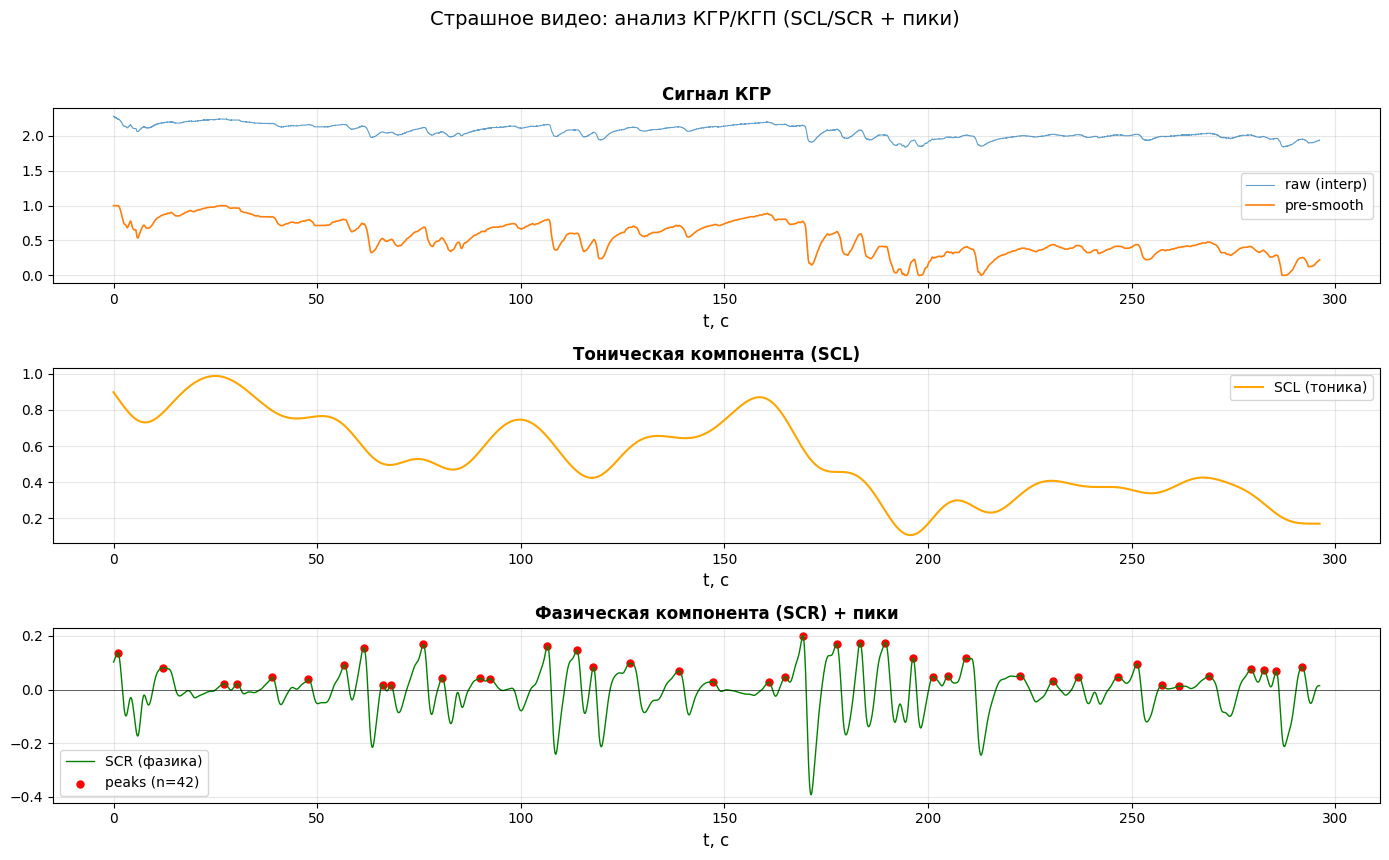

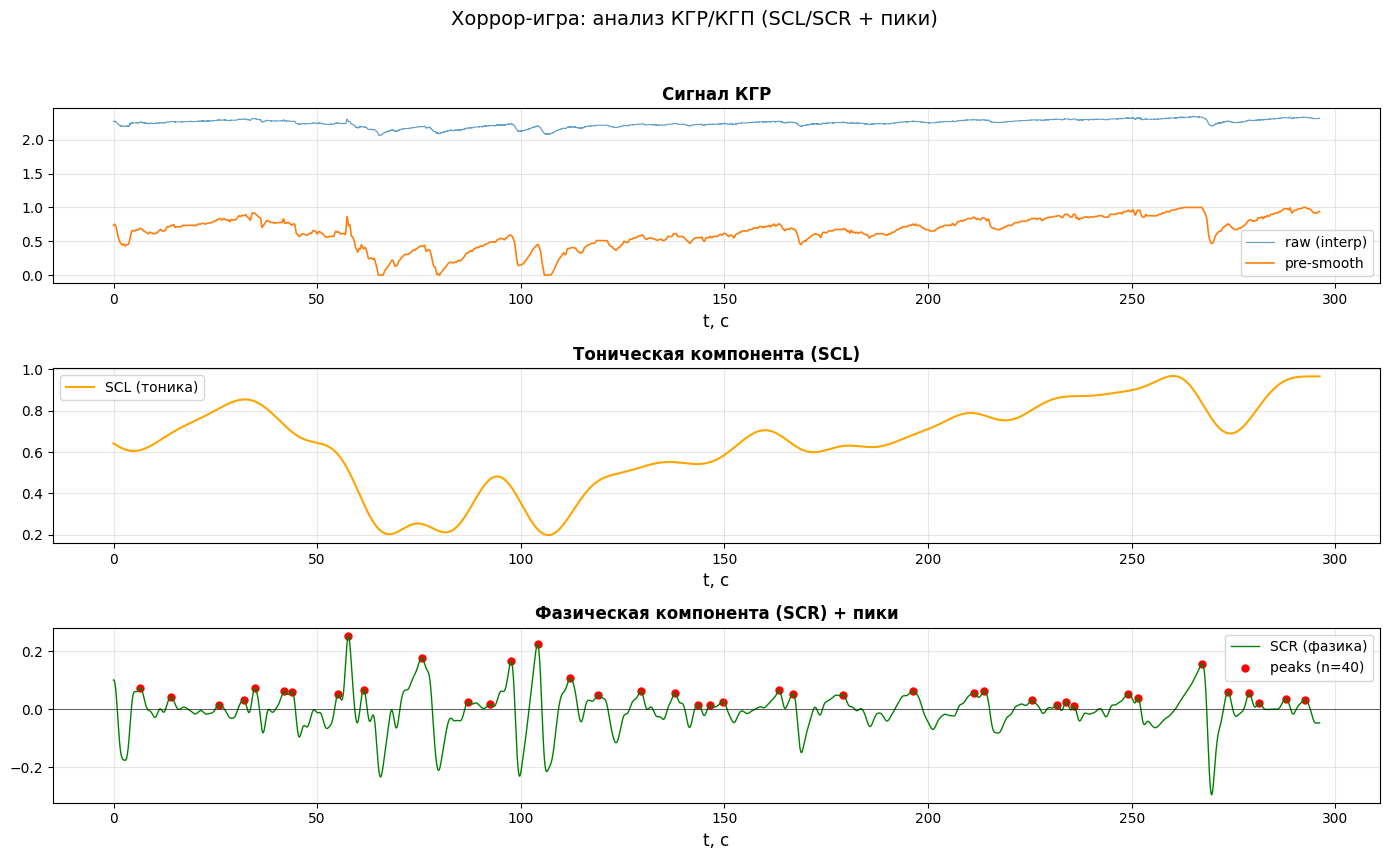

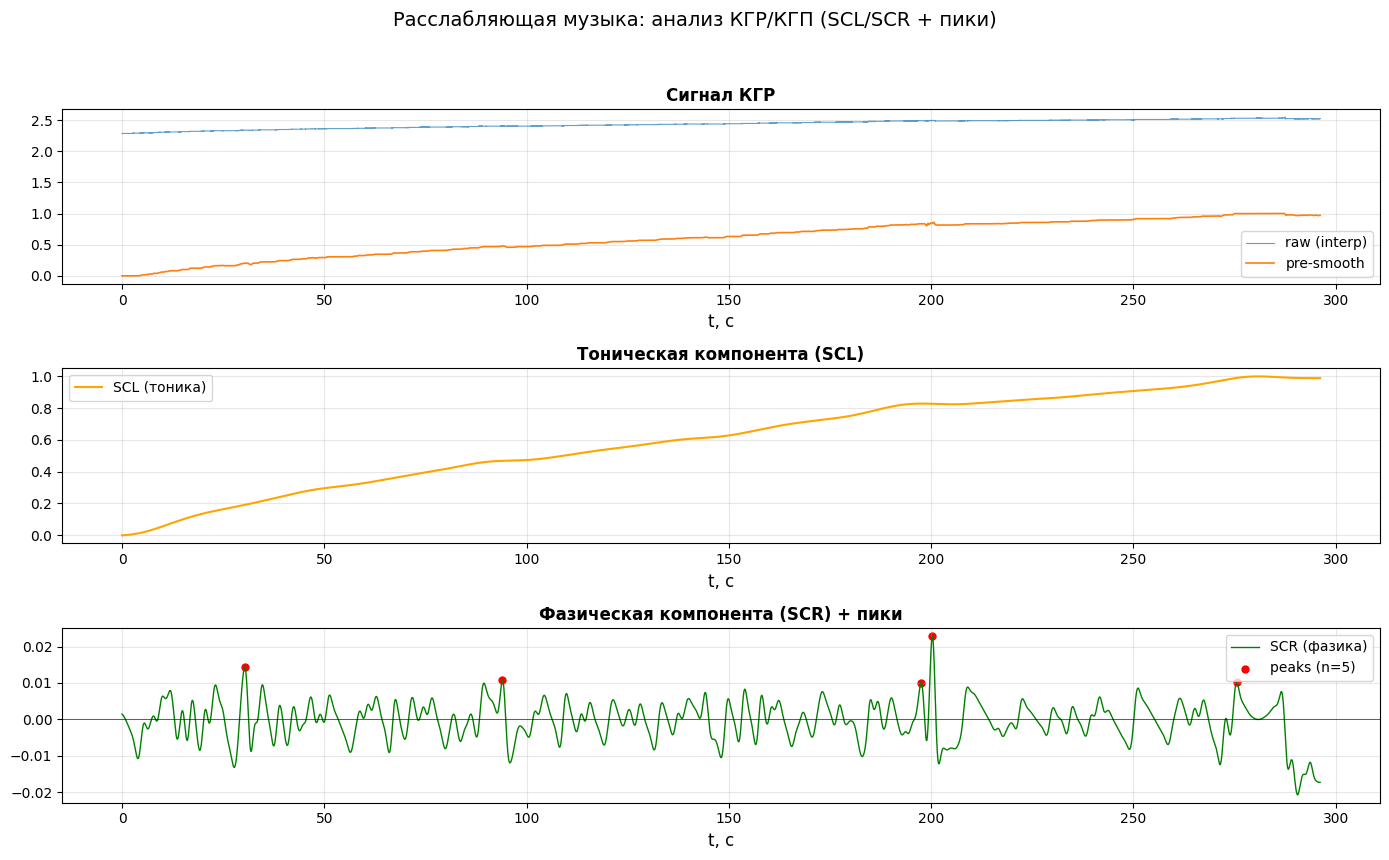

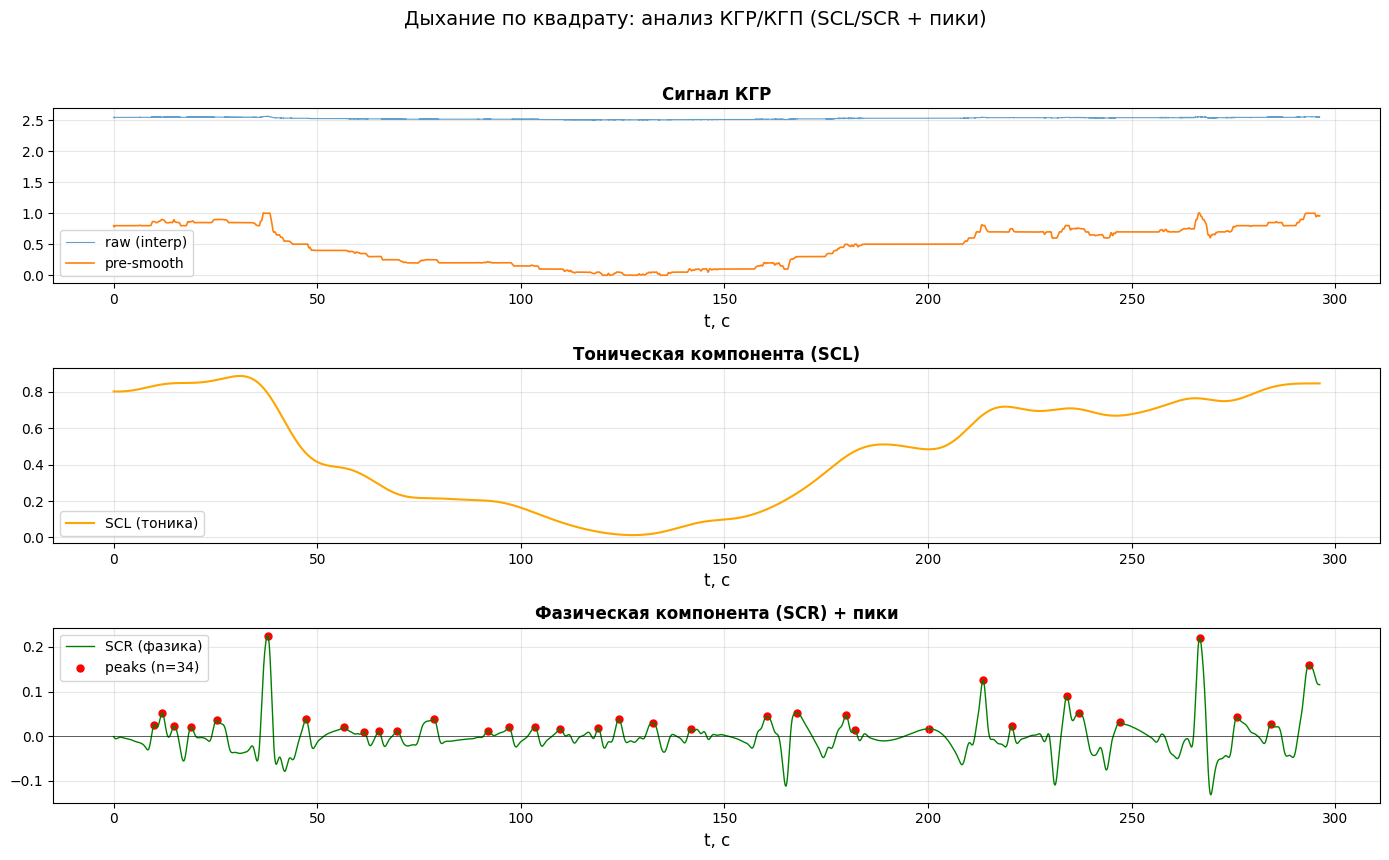

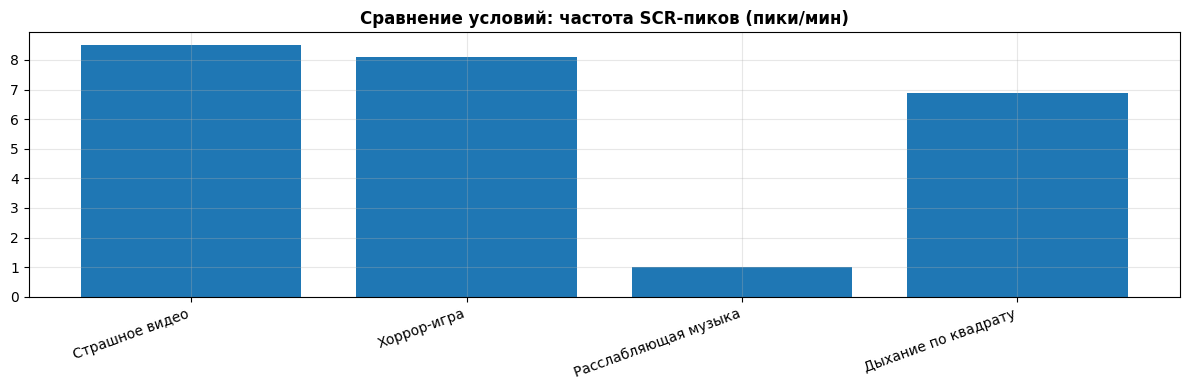

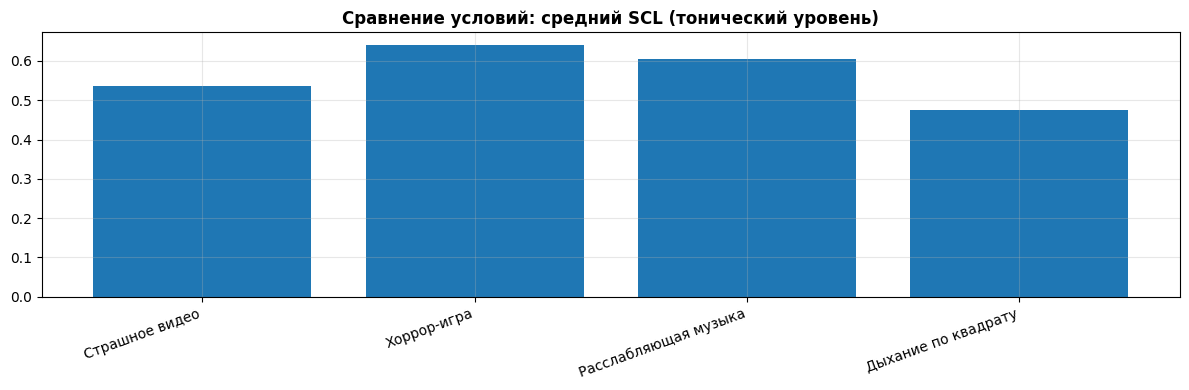

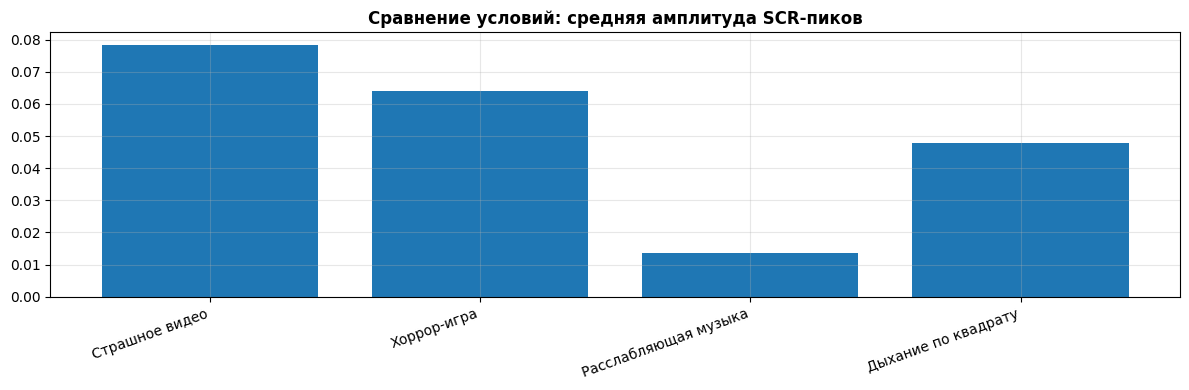

MAX peak_freq_per_min: {'condition': 'Страшное видео', 'peak_freq_per_min': 8.509223887263424}
MIN peak_freq_per_min: {'condition': 'Расслабляющая музыка', 'peak_freq_per_min': 1.0130028437218364}


In [ ]:
files = {
    "Страшное видео": "1_video.csv",
    "Хоррор-игра": "2_game.csv",
    "Расслабляющая музыка": "3_music.csv",
    "Дыхание по квадрату": "4_breath.csv",
}

results_df = run_kgp_lab(files, crop_start_sec=5.0, crop_duration_sec=300.0, show_plots_each=True)
results_df
compare_kgp_conditions(results_df)

# Быстрые экстремумы (по частоте пиков как индикатору стресса)
mx = results_df.loc[results_df["peak_freq_per_min"].idxmax(), ["condition", "peak_freq_per_min"]]
mn = results_df.loc[results_df["peak_freq_per_min"].idxmin(), ["condition", "peak_freq_per_min"]]
print("MAX peak_freq_per_min:", mx.to_dict())
print("MIN peak_freq_per_min:", mn.to_dict())


По графикам КГР/КГП видно, что стрессовые условия (страшное видео, хоррор-игра) приводят к росту симпатической активации - увеличивается частота и выраженность фазических реакций SCR (больше пиков и выше их амплитуда), тогда как при расслабляющей музыке наблюдается минимальная реактивность (самая низкая частота SCR-пиков: \~1.01 пик/мин) и более спокойный профиль сигнала; максимальная реактивность зафиксирована при страшном видео (~8.51 пика/мин), что соответствует наибольшему уровню эмоционального возбуждения/стресса. Тонический уровень SCL меняется медленнее и может содержать дрейф/адаптацию, поэтому для оценки "стресс <-> расслабление" наиболее информативны именно SCR-пики и их амплитуда: в целом эксперимент подтвердил, что стресс повышает кожно-гальваническую реактивность, а релаксация - снижает.